# C2CP canonical pathway coverage analysis

💡 **Environment:** `clamp-analyses`  

Analyzes the proportion of canonical pathways (C2CP) that are represented in CLAMPfull_C2CP models
trained with different random-sampling coverage settings (rs1%, rs5%, rs10%).

In [1]:
library(here)
library(ggplot2)
library(dplyr)

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Define GetCLAMPPathwayCoverage

In [2]:
GetCLAMPPathwayCoverage <- function(clamp.results, fdr.cutoff = 0.05, auc.cutoff = 0.6) {
  # Calculates the proportion of canonical pathways in the CLAMP prior
  # information matrix (C) that are significantly associated with at least
  # one latent variable (LV), the proportion of LVs with a pathway
  # associated, and the number of significant pathways per LV.
  #
  # Adapted from GetPathwayCoverage (J. Taroni 2018) for CLAMP models.
  # Key differences from PLIER:
  #   - summary column for LV is 'LV'    (PLIER uses 'LV index')
  #   - summary column for p-value is 'p_value' (PLIER uses 'p.value')
  #   - an additional AUC threshold is supported
  #
  # Args:
  #   clamp.results: output of CLAMPfull() -- a list containing at minimum
  #                  $U (pathways x LVs coefficient matrix),
  #                  $C (genes x pathways prior info matrix),
  #                  $summary (data.frame with columns pathway, LV, AUC,
  #                            p_value, FDR, npos, nneg)
  #   fdr.cutoff:    FDR threshold for significance (default 0.05)
  #   auc.cutoff:    AUC threshold for significance (default 0.6)
  #
  # Returns:
  #   A list with:
  #     pathway:           proportion of input pathways covered (>=1 sig LV)
  #     lv:                proportion of LVs with >=1 sig pathway
  #     sig.pathway.by.lv: number of significant pathways / number of LVs

  summary.df     <- clamp.results$summary
  input.pathways <- colnames(clamp.results$C)   # all pathways supplied as prior
  num.lvs        <- ncol(clamp.results$U)        # total number of LVs

  # Filter to significant pathway-LV associations
  sig.df <- summary.df[summary.df$FDR < fdr.cutoff & summary.df$AUC > auc.cutoff, ]

  sig.pathways <- unique(sig.df$pathway)
  sig.lvs      <- unique(sig.df$LV)

  return.list <- list()

  # Proportion of input pathways that have >=1 significantly associated LV
  return.list$pathway           <- length(sig.pathways) / length(input.pathways)

  # Proportion of LVs that have >=1 significantly associated pathway
  return.list$lv                <- length(sig.lvs) / num.lvs

  # Number of covered pathways per LV
  return.list$sig.pathway.by.lv <- length(sig.pathways) / num.lvs

  return(return.list)
}

## Load CLAMPfull_C2CP models and compute coverage

In [3]:
output_dir <- here("output/archs4")

# Define available models: (coverage %, seed)
model_specs <- list(
  list(coverage = 1,   seed = 1),
  list(coverage = 1,   seed = 2),
  list(coverage = 1,   seed = 3),
  list(coverage = 5,   seed = 1),
  list(coverage = 5,   seed = 2),
  list(coverage = 5,   seed = 3),
  list(coverage = 10,  seed = 1),
  list(coverage = 10,  seed = 2),
  list(coverage = 10,  seed = 3),
  list(coverage = 25,  seed = 1),
  list(coverage = 25,  seed = 2),
  list(coverage = 25,  seed = 3),
  list(coverage = 50,  seed = 1),
  list(coverage = 50,  seed = 2),
  list(coverage = 50,  seed = 3),
  list(coverage = 75,  seed = 1),
  list(coverage = 75,  seed = 2),
  list(coverage = 75,  seed = 3),
  list(coverage = 100, seed = 1),
  list(coverage = 100, seed = 2),
  list(coverage = 100, seed = 3)
)

results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("c2cp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_C2CP.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.1)

  data.frame(
    name               = sprintf("c2cp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
rownames(results_df) <- NULL

print(results_df)

Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/c2cp_coverage_rs100_seed_1/CLAMPfull_C2CP.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/c2cp_coverage_rs100_seed_2/CLAMPfull_C2CP.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/c2cp_coverage_rs100_seed_3/CLAMPfull_C2CP.rds”


                        name coverage_pct seed n_samples n_input_pathways n_lvs
1   c2cp_coverage_rs1_seed_1            1    1      6056             3109   128
2   c2cp_coverage_rs1_seed_2            1    2      6056             3109   128
3   c2cp_coverage_rs1_seed_3            1    3      6056             3109   130
4   c2cp_coverage_rs5_seed_1            5    1     30281             3109   704
5   c2cp_coverage_rs5_seed_2            5    2     30281             3109   698
6   c2cp_coverage_rs5_seed_3            5    3     30281             3109   710
7  c2cp_coverage_rs10_seed_1           10    1     60561             3109   950
8  c2cp_coverage_rs10_seed_2           10    2     60561             3109   952
9  c2cp_coverage_rs10_seed_3           10    3     60561             3109   952
10 c2cp_coverage_rs25_seed_1           25    1    151404             3109  1328
11 c2cp_coverage_rs25_seed_2           25    2    151404             3109  1324
12 c2cp_coverage_rs25_seed_3           2

## Boxplot: pathway coverage per % (ordered by descending coverage)

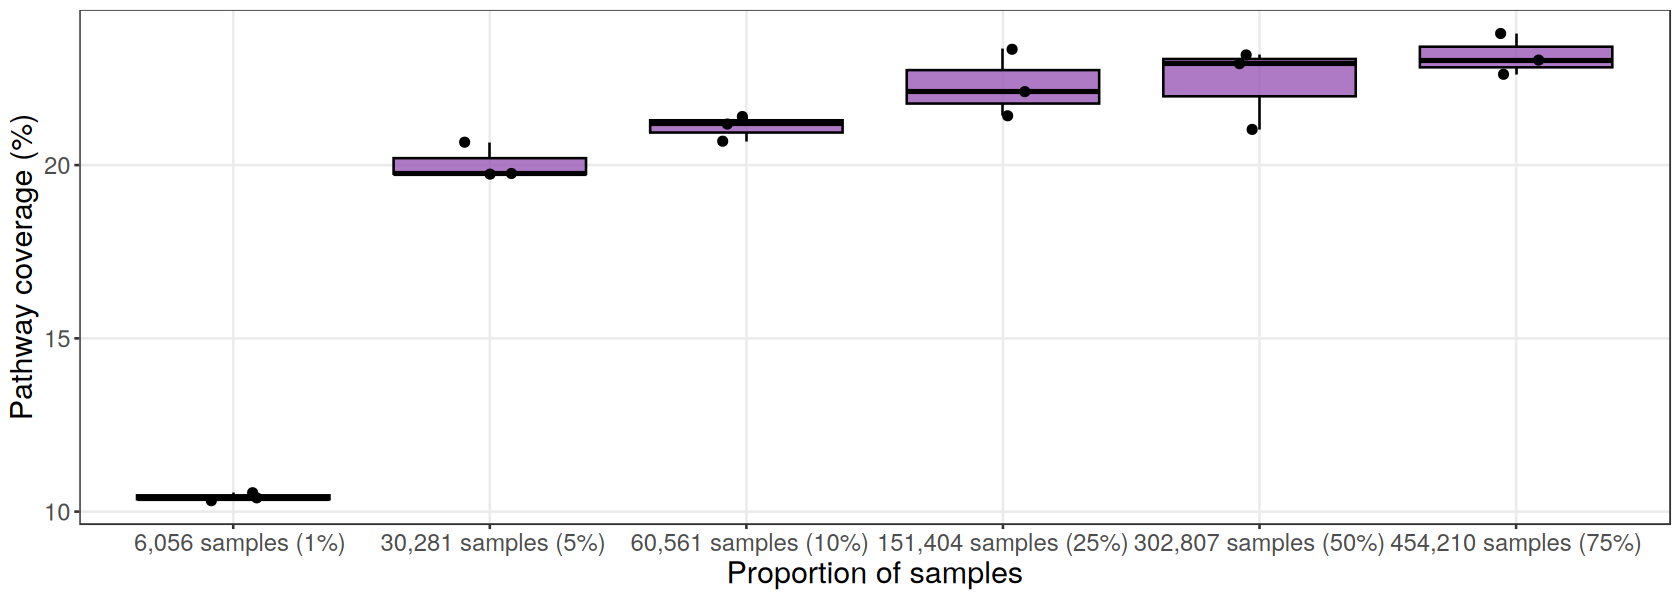

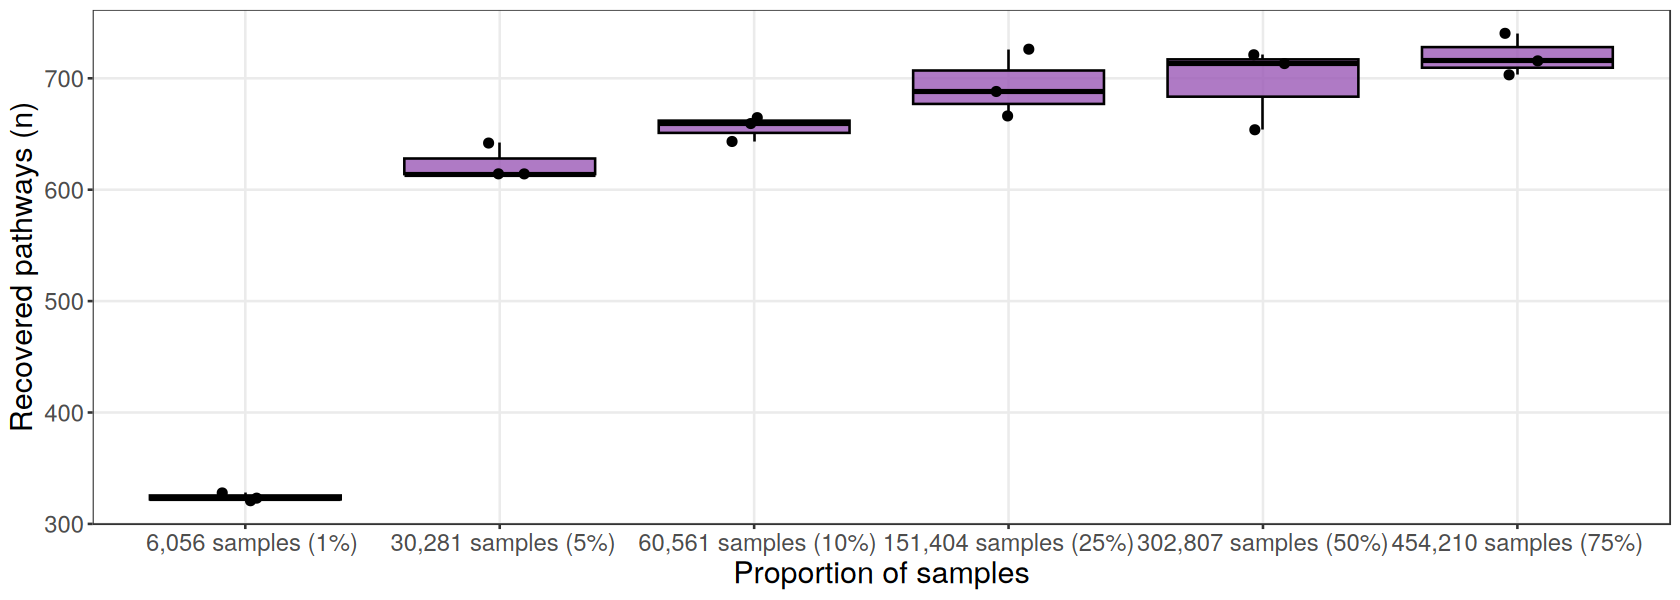

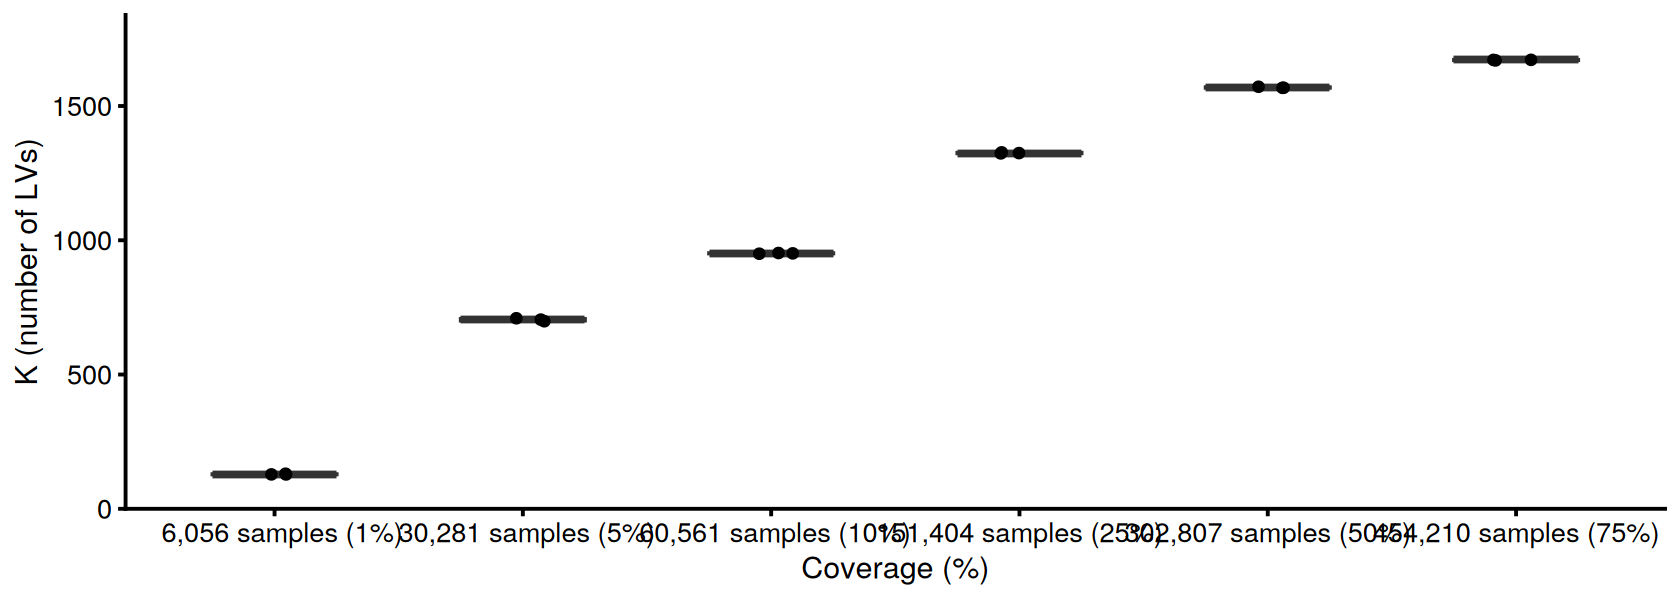

In [4]:
options(repr.plot.width = 14, repr.plot.height = 5)

sample_counts <- results_df %>%
  group_by(coverage_pct) %>%
  summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  arrange(coverage_pct)

label_map <- setNames(
  paste0(format(sample_counts$med_n, big.mark = ","), " samples (", sample_counts$coverage_pct, "%)"),
  sample_counts$coverage_pct
)

results_df$coverage_label <- factor(
  label_map[as.character(results_df$coverage_pct)],
  levels = label_map
)

ggplot(results_df, aes(x = coverage_label, y = prop_pathway * 100)) +
  geom_boxplot(fill = "#9b59b6", colour = "black", alpha = 0.8,
               outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, colour = "black", alpha = 1) +
  labs(
    x = "Proportion of samples",
    y = "Pathway coverage (%)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title       = element_text(hjust = 0.5, size = 11),
    panel.grid.minor = element_blank(),
    legend.position  = "none",
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 14)
  )

results_df$n_sig_pathways <- round(results_df$prop_pathway * results_df$n_input_pathways)

ggplot(results_df, aes(x = coverage_label, y = n_sig_pathways)) +
  geom_boxplot(fill = "#9b59b6", colour = "black", alpha = 0.8,
               outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, colour = "black", alpha = 1) +
  labs(
    x = "Proportion of samples",
    y = "Recovered pathways (n)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title       = element_text(hjust = 0.5, size = 11),
    panel.grid.minor = element_blank(),
    legend.position  = "none",
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 14)
  )


ggplot(results_df, aes(x = coverage_label, y = n_lvs, fill = coverage_label)) +
  geom_boxplot(width = 0.5, outlier.shape = 21, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, alpha = 1) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1))) +
  labs(
    x     = "Coverage (%)",
    y     = "K (number of LVs)"
  ) +
  theme_classic(base_size = 18) +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 20),
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 16)
  )

In [5]:
output_dir <- here("output/archs4")

# Define available models: (coverage %, seed)
model_specs <- list(
  list(coverage = 1,   seed = 1),
  list(coverage = 1,   seed = 2),
  list(coverage = 1,   seed = 3),
  list(coverage = 5,   seed = 1),
  list(coverage = 5,   seed = 2),
  list(coverage = 5,   seed = 3),
  list(coverage = 10,  seed = 1),
  list(coverage = 10,  seed = 2),
  list(coverage = 10,  seed = 3),
  list(coverage = 25,  seed = 1),
  list(coverage = 25,  seed = 2),
  list(coverage = 25,  seed = 3),
  list(coverage = 50,  seed = 1),
  list(coverage = 50,  seed = 2),
  list(coverage = 50,  seed = 3),
  list(coverage = 75,  seed = 1),
  list(coverage = 75,  seed = 2),
  list(coverage = 75,  seed = 3),
  list(coverage = 100, seed = 1),
  list(coverage = 100, seed = 2),
  list(coverage = 100, seed = 3)
)

results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("c2cp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_C2CP.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.05)

  data.frame(
    name               = sprintf("c2cp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
rownames(results_df) <- NULL

print(results_df)

Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/c2cp_coverage_rs100_seed_1/CLAMPfull_C2CP.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/c2cp_coverage_rs100_seed_2/CLAMPfull_C2CP.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/c2cp_coverage_rs100_seed_3/CLAMPfull_C2CP.rds”


                        name coverage_pct seed n_samples n_input_pathways n_lvs
1   c2cp_coverage_rs1_seed_1            1    1      6056             3109   128
2   c2cp_coverage_rs1_seed_2            1    2      6056             3109   128
3   c2cp_coverage_rs1_seed_3            1    3      6056             3109   130
4   c2cp_coverage_rs5_seed_1            5    1     30281             3109   704
5   c2cp_coverage_rs5_seed_2            5    2     30281             3109   698
6   c2cp_coverage_rs5_seed_3            5    3     30281             3109   710
7  c2cp_coverage_rs10_seed_1           10    1     60561             3109   950
8  c2cp_coverage_rs10_seed_2           10    2     60561             3109   952
9  c2cp_coverage_rs10_seed_3           10    3     60561             3109   952
10 c2cp_coverage_rs25_seed_1           25    1    151404             3109  1328
11 c2cp_coverage_rs25_seed_2           25    2    151404             3109  1324
12 c2cp_coverage_rs25_seed_3           2

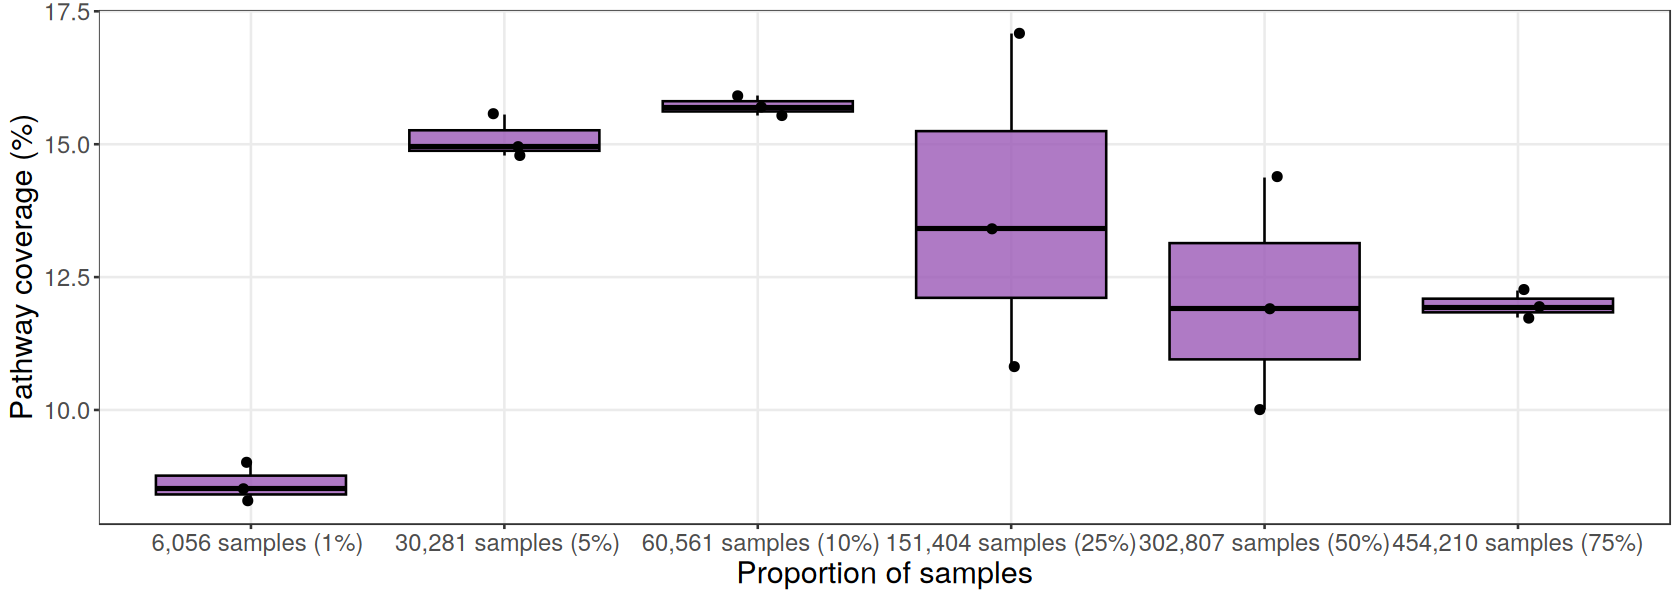

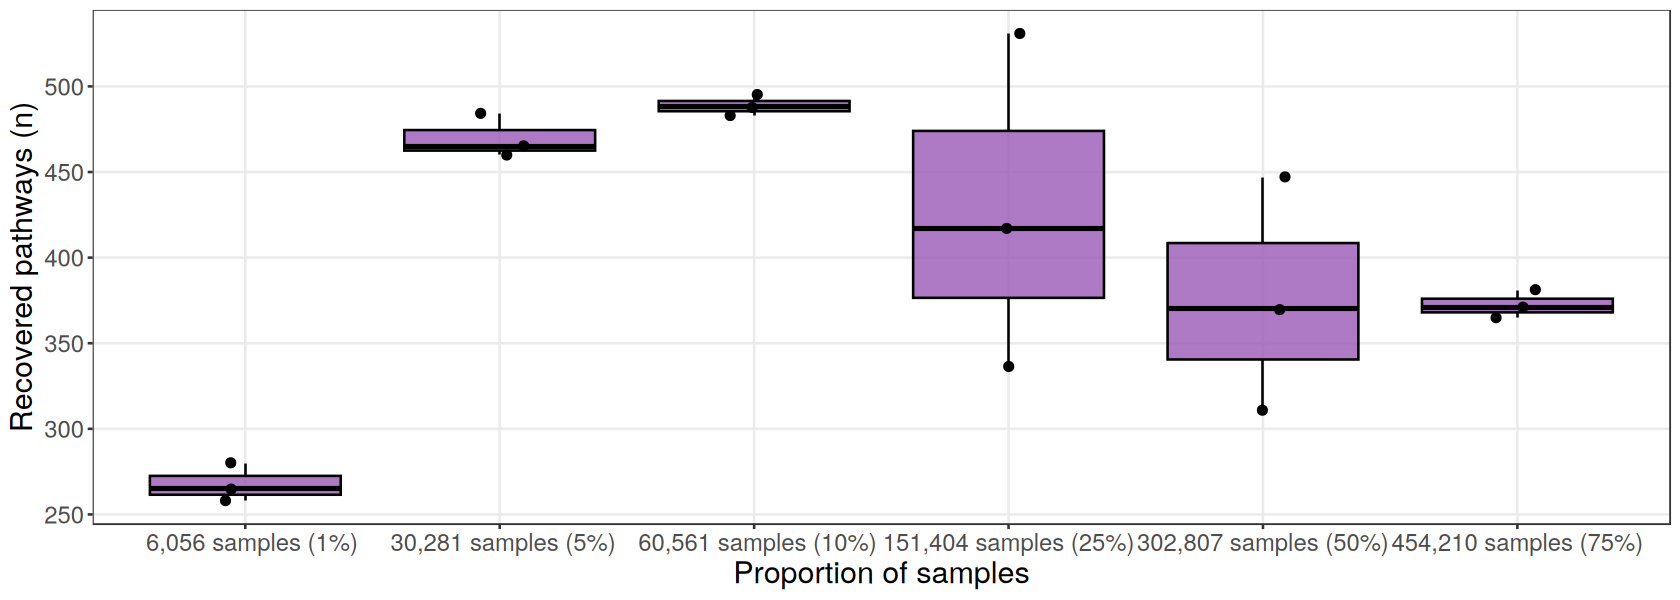

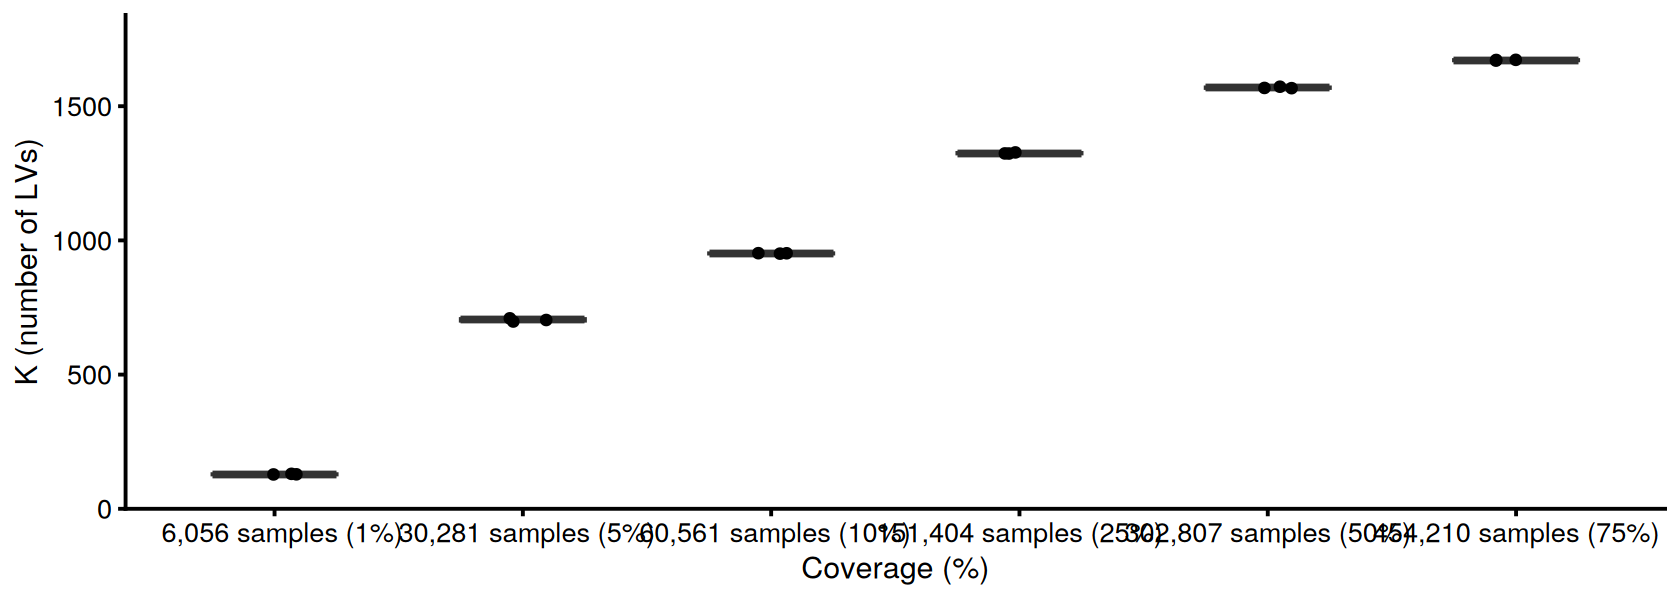

In [6]:
options(repr.plot.width = 14, repr.plot.height = 5)

sample_counts <- results_df %>%
  group_by(coverage_pct) %>%
  summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  arrange(coverage_pct)

label_map <- setNames(
  paste0(format(sample_counts$med_n, big.mark = ","), " samples (", sample_counts$coverage_pct, "%)"),
  sample_counts$coverage_pct
)

results_df$coverage_label <- factor(
  label_map[as.character(results_df$coverage_pct)],
  levels = label_map
)

ggplot(results_df, aes(x = coverage_label, y = prop_pathway * 100)) +
  geom_boxplot(fill = "#9b59b6", colour = "black", alpha = 0.8,
               outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, colour = "black", alpha = 1) +
  labs(
    x = "Proportion of samples",
    y = "Pathway coverage (%)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title       = element_text(hjust = 0.5, size = 11),
    panel.grid.minor = element_blank(),
    legend.position  = "none",
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 14)
  )

results_df$n_sig_pathways <- round(results_df$prop_pathway * results_df$n_input_pathways)

ggplot(results_df, aes(x = coverage_label, y = n_sig_pathways)) +
  geom_boxplot(fill = "#9b59b6", colour = "black", alpha = 0.8,
               outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, colour = "black", alpha = 1) +
  labs(
    x = "Proportion of samples",
    y = "Recovered pathways (n)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title       = element_text(hjust = 0.5, size = 11),
    panel.grid.minor = element_blank(),
    legend.position  = "none",
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 14)
  )


ggplot(results_df, aes(x = coverage_label, y = n_lvs, fill = coverage_label)) +
  geom_boxplot(width = 0.5, outlier.shape = 21, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, alpha = 1) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1))) +
  labs(
    x     = "Coverage (%)",
    y     = "K (number of LVs)"
  ) +
  theme_classic(base_size = 18) +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 20),
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 16)
  )

## Load CLAMPfull_msigdb models and compute coverage

In [7]:
msigdb_results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("msigdb_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_msigdb.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.05)

  data.frame(
    name               = sprintf("msigdb_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

msigdb_results_df <- do.call(rbind, Filter(Negate(is.null), msigdb_results))
rownames(msigdb_results_df) <- NULL

print(msigdb_results_df)

Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/msigdb_coverage_rs100_seed_1/CLAMPfull_msigdb.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/msigdb_coverage_rs100_seed_2/CLAMPfull_msigdb.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/msigdb_coverage_rs100_seed_3/CLAMPfull_msigdb.rds”


                          name coverage_pct seed n_samples n_input_pathways
1   msigdb_coverage_rs1_seed_1            1    1      6056            28320
2   msigdb_coverage_rs1_seed_2            1    2      6056            28320
3   msigdb_coverage_rs1_seed_3            1    3      6056            28320
4   msigdb_coverage_rs5_seed_1            5    1     30281            28320
5   msigdb_coverage_rs5_seed_2            5    2     30281            28320
6   msigdb_coverage_rs5_seed_3            5    3     30281            28320
7  msigdb_coverage_rs10_seed_1           10    1     60561            28320
8  msigdb_coverage_rs10_seed_2           10    2     60561            28320
9  msigdb_coverage_rs10_seed_3           10    3     60561            28320
10 msigdb_coverage_rs25_seed_1           25    1    151404            28320
11 msigdb_coverage_rs25_seed_2           25    2    151404            28320
12 msigdb_coverage_rs25_seed_3           25    3    151404            28320
13 msigdb_co

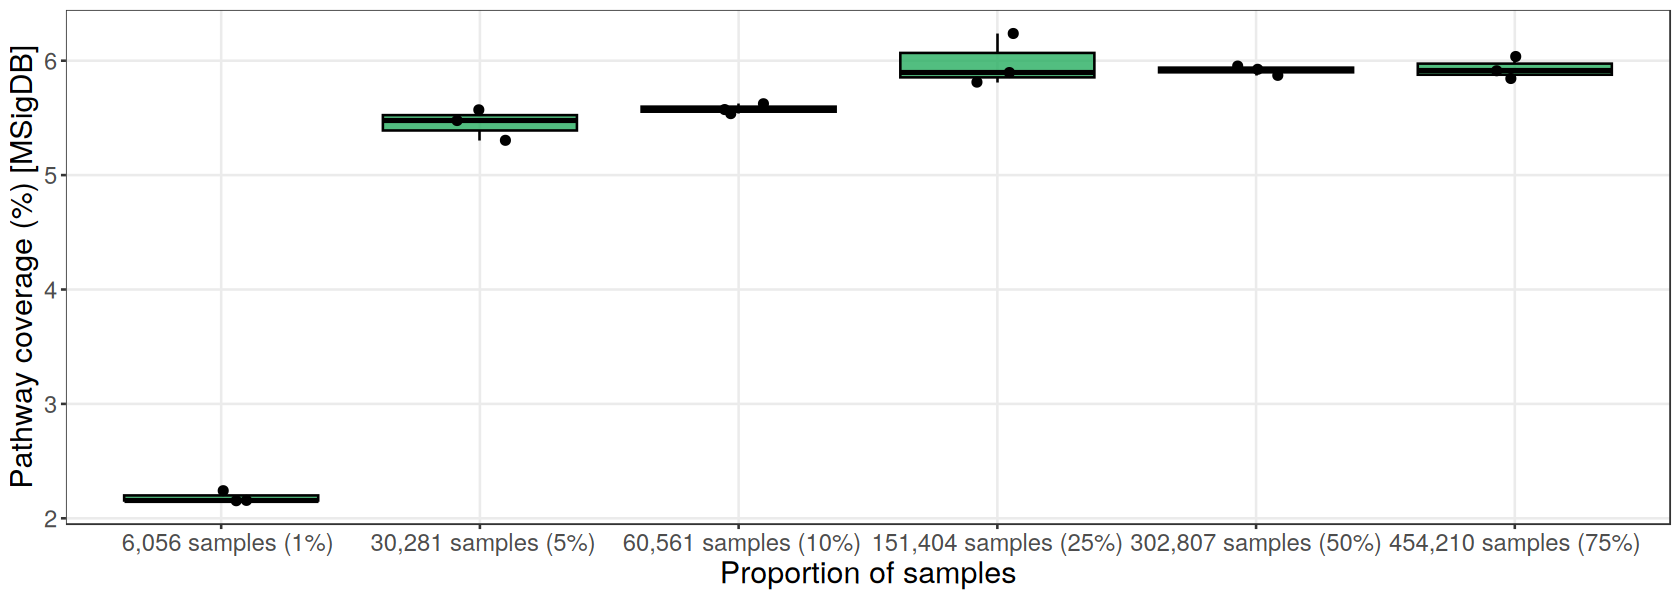

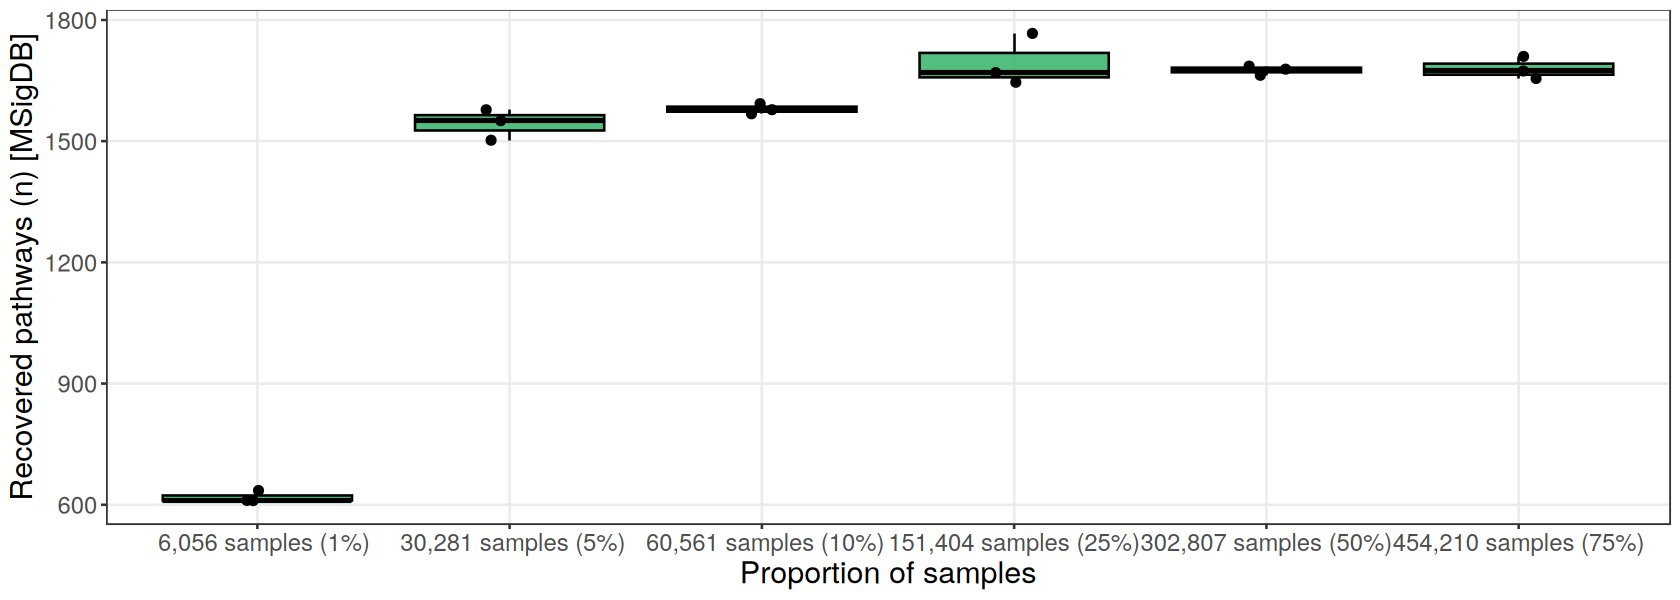

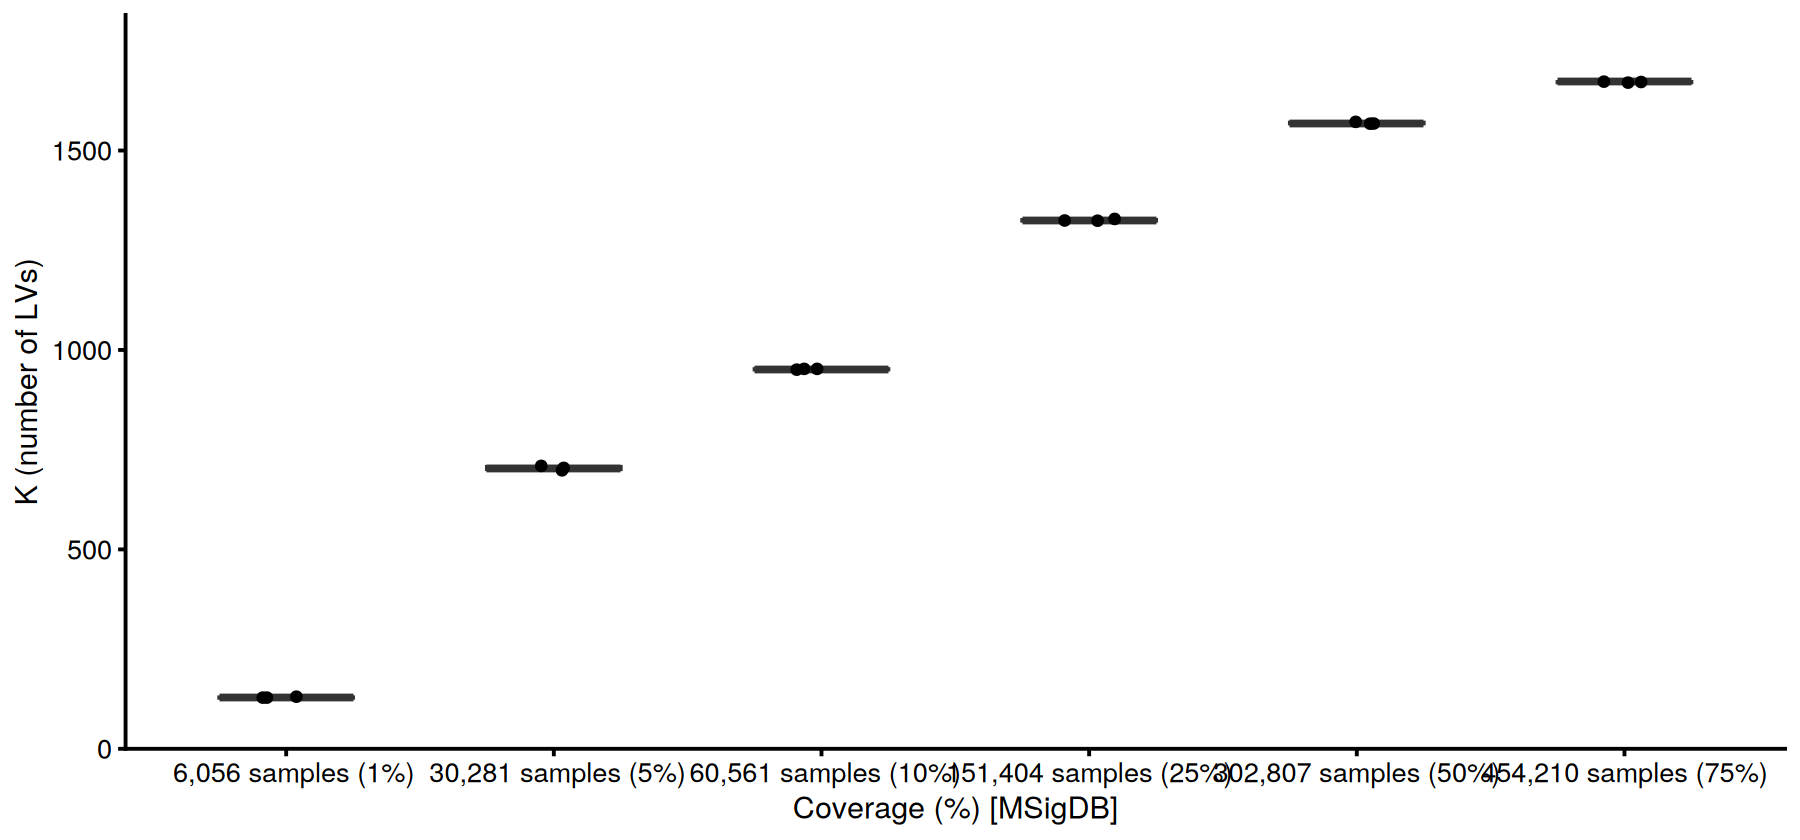

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 6.5)

msigdb_sample_counts <- msigdb_results_df %>%
  group_by(coverage_pct) %>%
  summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  arrange(coverage_pct)

msigdb_label_map <- setNames(
  paste0(
    format(msigdb_sample_counts$med_n, big.mark = ","),
    " samples (", msigdb_sample_counts$coverage_pct, "%)"
  ),
  msigdb_sample_counts$coverage_pct
)

msigdb_results_df <- msigdb_results_df %>%
  mutate(
    coverage_label = factor(
      msigdb_label_map[as.character(coverage_pct)],
      levels = msigdb_label_map
    ),
    n_sig_pathways = round(prop_pathway * n_input_pathways)
  )

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title = element_text(size = 24, colour = "black"),
      axis.text = element_text(size = 18, colour = "black"),
      axis.line = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      plot.title = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = 18),
      plot.margin = margin(t = 16, r = 12, b = 12, l = 12)
    )
}

green_fill <- "#27ae60"

prop_offset <- 0.28
nsig_offset <- 85
lvs_offset  <- 95

mean_prop_df <- msigdb_results_df %>%
  group_by(coverage_label) %>%
  summarise(
    mean_y = mean(prop_pathway * 100, na.rm = TRUE),
    max_y = max(prop_pathway * 100, na.rm = TRUE),
    label_y = max_y + prop_offset,
    label = paste0(sprintf("%.1f", mean_y), "%"),
    .groups = "drop"
  )

mean_nsig_df <- msigdb_results_df %>%
  group_by(coverage_label) %>%
  summarise(
    mean_y = mean(n_sig_pathways, na.rm = TRUE),
    max_y = max(n_sig_pathways, na.rm = TRUE),
    label_y = max_y + nsig_offset,
    label = sprintf("%.0f", mean_y),
    .groups = "drop"
  )

mean_lvs_df <- msigdb_results_df %>%
  group_by(coverage_label) %>%
  summarise(
    mean_y = mean(n_lvs, na.rm = TRUE),
    max_y = max(n_lvs, na.rm = TRUE),
    label_y = max_y + lvs_offset,
    label = sprintf("%.0f", mean_y),
    .groups = "drop"
  )

p1 <- ggplot(msigdb_results_df, aes(x = coverage_label, y = prop_pathway * 100)) +
  geom_boxplot(
    width = 0.55,
    fill = alpha(green_fill, 0.80),
    colour = "black",
    linewidth = 0.8,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.08,
    size = 2.8,
    shape = 21,
    fill = "white",
    colour = "#2b2b2b",
    stroke = 0.5,
    alpha = 0.95
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 23,
    size = 3.8,
    fill = "white",
    colour = "black",
    stroke = 0.8
  ) +
  geom_text(
    data = mean_prop_df,
    aes(x = coverage_label, y = label_y, label = label),
    inherit.aes = FALSE,
    size = 6.2,
    fontface = "bold",
    vjust = 0
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.18))
  ) +
  labs(
    x = "Proportion of samples",
    y = "Pathway coverage (%)"
  ) +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1)
  )

p1

options(repr.plot.width = 16, repr.plot.height = 6.5)

p2 <- ggplot(msigdb_results_df, aes(x = coverage_label, y = n_sig_pathways)) +
  geom_boxplot(
    width = 0.55,
    fill = alpha(green_fill, 0.80),
    colour = "black",
    linewidth = 0.8,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.08,
    size = 2.8,
    shape = 21,
    fill = "white",
    colour = "#2b2b2b",
    stroke = 0.5,
    alpha = 0.95
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 23,
    size = 3.8,
    fill = "white",
    colour = "black",
    stroke = 0.8
  ) +
  geom_text(
    data = mean_nsig_df,
    aes(x = coverage_label, y = label_y, label = label),
    inherit.aes = FALSE,
    size = 6.2,
    fontface = "bold",
    vjust = 0
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.22))
  ) +
  labs(
    x = "Proportion of samples",
    y = "Recovered pathways"
  ) +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1)
  )

p2

options(repr.plot.width = 16, repr.plot.height = 6.5)

p3 <- ggplot(msigdb_results_df, aes(x = coverage_label, y = n_lvs)) +
  geom_boxplot(
    width = 0.55,
    fill = alpha(green_fill, 0.80),
    colour = "black",
    linewidth = 0.8,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.08,
    size = 2.8,
    shape = 21,
    fill = "white",
    colour = "#2b2b2b",
    stroke = 0.5,
    alpha = 0.95
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 23,
    size = 3.8,
    fill = "white",
    colour = "black",
    stroke = 0.8
  ) +
  geom_text(
    data = mean_lvs_df,
    aes(x = coverage_label, y = label_y, label = label),
    inherit.aes = FALSE,
    size = 6.2,
    fontface = "bold",
    vjust = 0
  ) +
  scale_y_continuous(
    limits = c(0, NA),
    expand = expansion(mult = c(0, 0.22))
  ) +
  labs(
    x = "Proportion of samples",
    y = "K (number of LVs)"
  ) +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1)
  )

p3

In [9]:
msigdb_results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("msigdb_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_msigdb.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.1)

  data.frame(
    name               = sprintf("msigdb_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

msigdb_results_df <- do.call(rbind, Filter(Negate(is.null), msigdb_results))
rownames(msigdb_results_df) <- NULL

print(msigdb_results_df)

Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/msigdb_coverage_rs100_seed_1/CLAMPfull_msigdb.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/msigdb_coverage_rs100_seed_2/CLAMPfull_msigdb.rds”
Warning message in FUN(X[[i]], ...):
“File not found: /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/msigdb_coverage_rs100_seed_3/CLAMPfull_msigdb.rds”


                          name coverage_pct seed n_samples n_input_pathways
1   msigdb_coverage_rs1_seed_1            1    1      6056            28320
2   msigdb_coverage_rs1_seed_2            1    2      6056            28320
3   msigdb_coverage_rs1_seed_3            1    3      6056            28320
4   msigdb_coverage_rs5_seed_1            5    1     30281            28320
5   msigdb_coverage_rs5_seed_2            5    2     30281            28320
6   msigdb_coverage_rs5_seed_3            5    3     30281            28320
7  msigdb_coverage_rs10_seed_1           10    1     60561            28320
8  msigdb_coverage_rs10_seed_2           10    2     60561            28320
9  msigdb_coverage_rs10_seed_3           10    3     60561            28320
10 msigdb_coverage_rs25_seed_1           25    1    151404            28320
11 msigdb_coverage_rs25_seed_2           25    2    151404            28320
12 msigdb_coverage_rs25_seed_3           25    3    151404            28320
13 msigdb_co

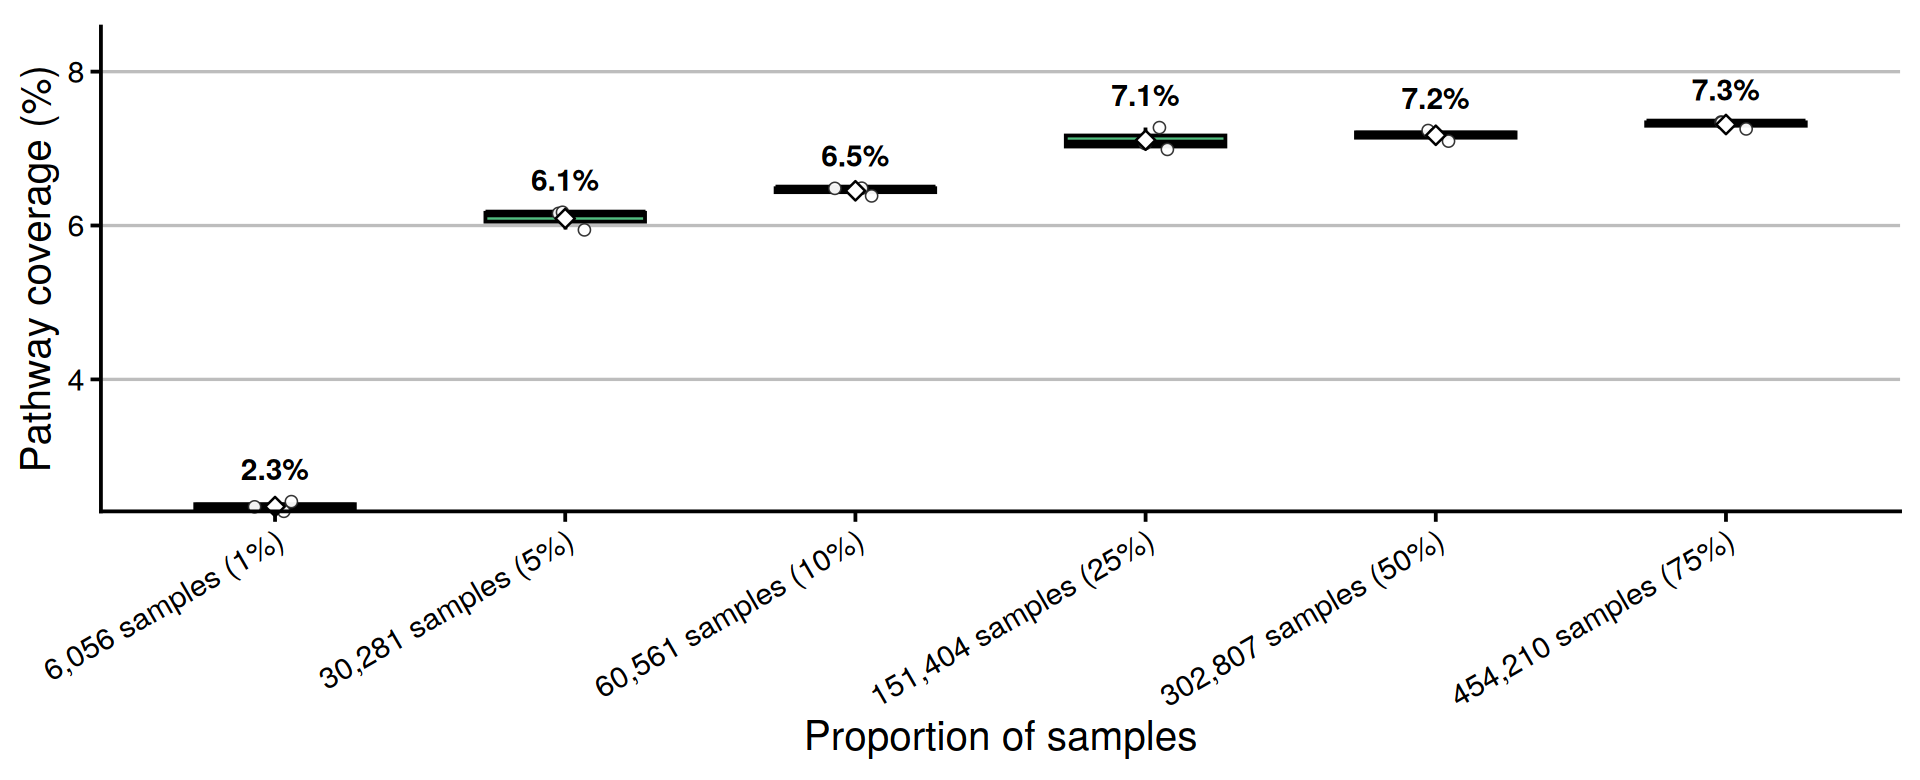

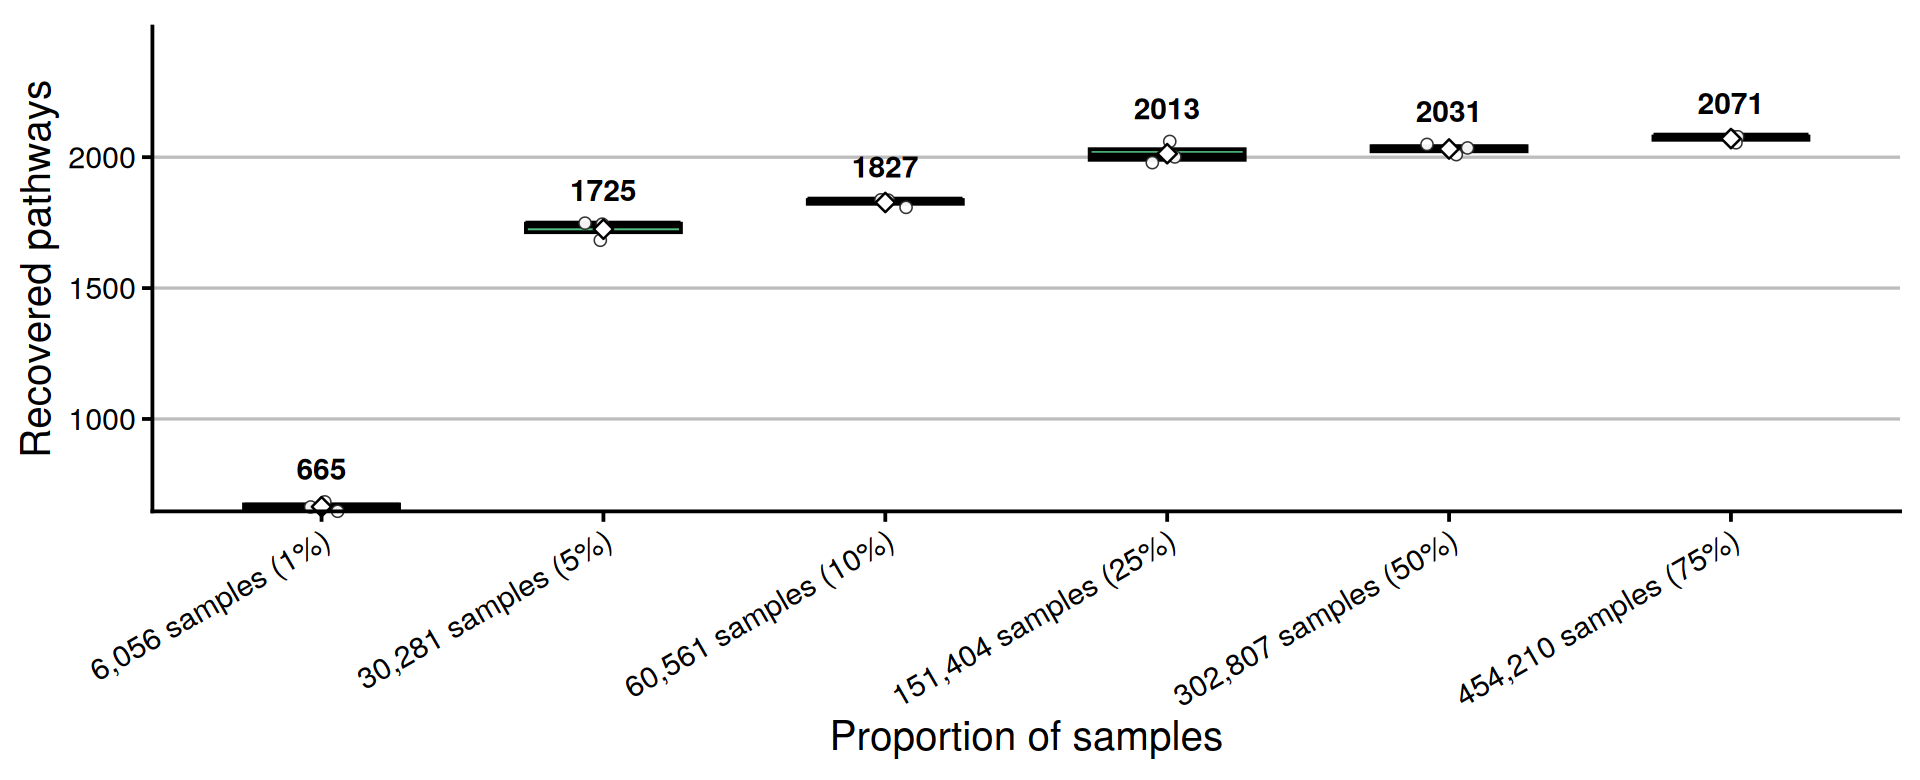

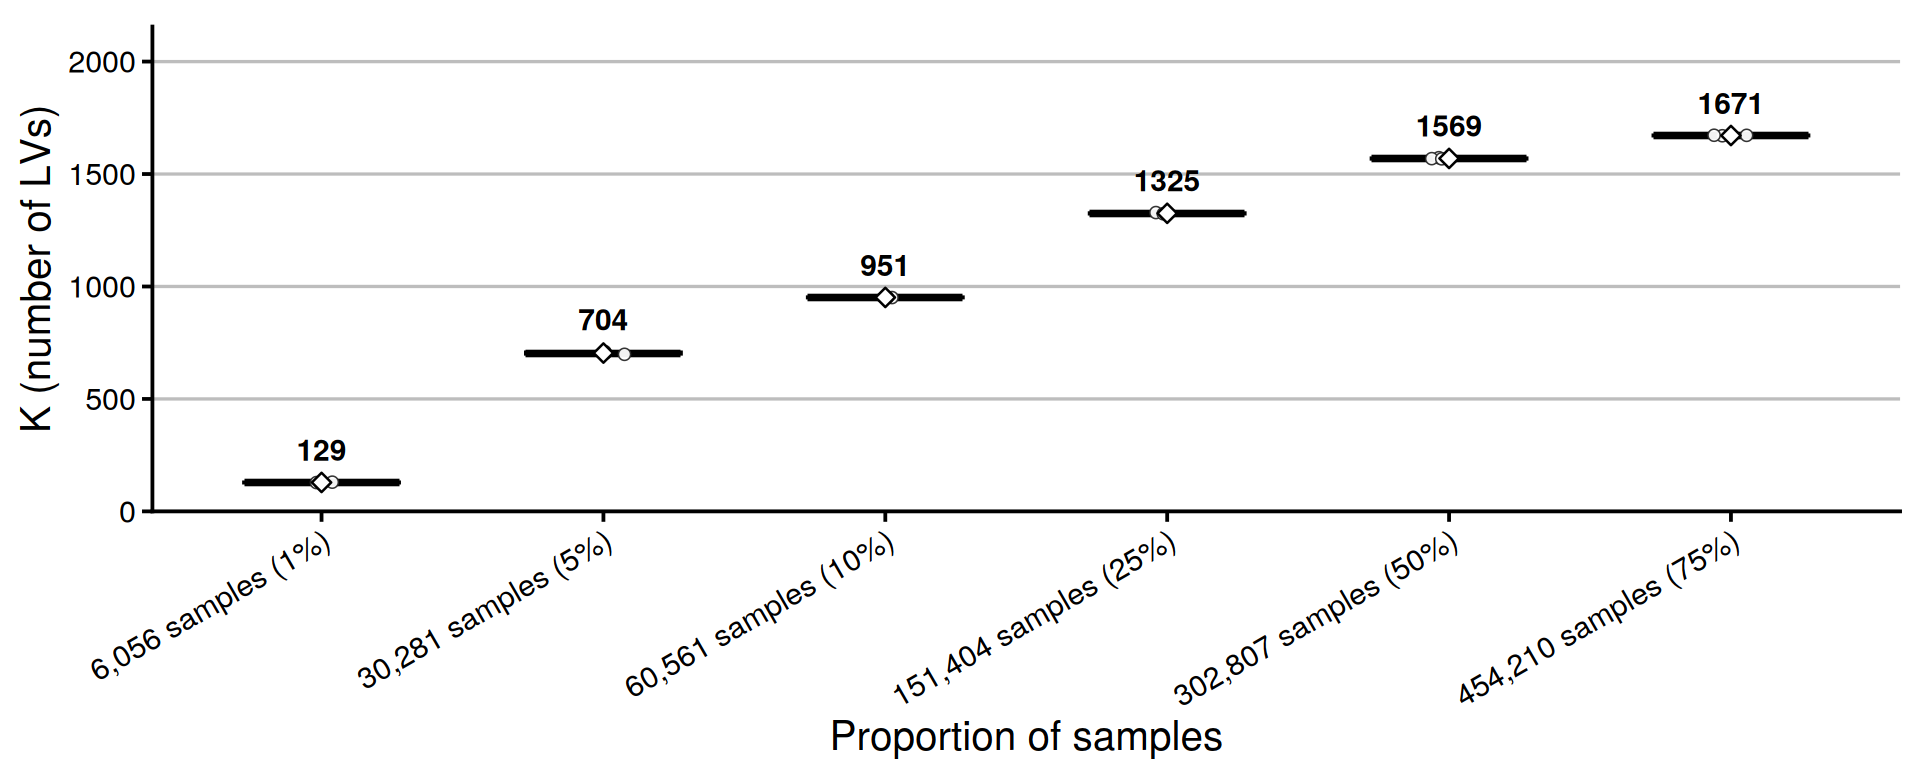

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 6.5)

msigdb_sample_counts <- msigdb_results_df %>%
  group_by(coverage_pct) %>%
  summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  arrange(coverage_pct)

msigdb_label_map <- setNames(
  paste0(
    format(msigdb_sample_counts$med_n, big.mark = ","),
    " samples (", msigdb_sample_counts$coverage_pct, "%)"
  ),
  msigdb_sample_counts$coverage_pct
)

msigdb_results_df <- msigdb_results_df %>%
  mutate(
    coverage_label = factor(
      msigdb_label_map[as.character(coverage_pct)],
      levels = msigdb_label_map
    ),
    n_sig_pathways = round(prop_pathway * n_input_pathways)
  )

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title = element_text(size = 24, colour = "black"),
      axis.text = element_text(size = 18, colour = "black"),
      axis.line = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      plot.title = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = 18),
      plot.margin = margin(t = 16, r = 12, b = 12, l = 12)
    )
}

green_fill <- "#27ae60"

prop_offset <- 0.28
nsig_offset <- 85
lvs_offset  <- 95

mean_prop_df <- msigdb_results_df %>%
  group_by(coverage_label) %>%
  summarise(
    mean_y = mean(prop_pathway * 100, na.rm = TRUE),
    max_y = max(prop_pathway * 100, na.rm = TRUE),
    label_y = max_y + prop_offset,
    label = paste0(sprintf("%.1f", mean_y), "%"),
    .groups = "drop"
  )

mean_nsig_df <- msigdb_results_df %>%
  group_by(coverage_label) %>%
  summarise(
    mean_y = mean(n_sig_pathways, na.rm = TRUE),
    max_y = max(n_sig_pathways, na.rm = TRUE),
    label_y = max_y + nsig_offset,
    label = sprintf("%.0f", mean_y),
    .groups = "drop"
  )

mean_lvs_df <- msigdb_results_df %>%
  group_by(coverage_label) %>%
  summarise(
    mean_y = mean(n_lvs, na.rm = TRUE),
    max_y = max(n_lvs, na.rm = TRUE),
    label_y = max_y + lvs_offset,
    label = sprintf("%.0f", mean_y),
    .groups = "drop"
  )

p1 <- ggplot(msigdb_results_df, aes(x = coverage_label, y = prop_pathway * 100)) +
  geom_boxplot(
    width = 0.55,
    fill = alpha(green_fill, 0.80),
    colour = "black",
    linewidth = 0.8,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.08,
    size = 2.8,
    shape = 21,
    fill = "white",
    colour = "#2b2b2b",
    stroke = 0.5,
    alpha = 0.95
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 23,
    size = 3.8,
    fill = "white",
    colour = "black",
    stroke = 0.8
  ) +
  geom_text(
    data = mean_prop_df,
    aes(x = coverage_label, y = label_y, label = label),
    inherit.aes = FALSE,
    size = 6.2,
    fontface = "bold",
    vjust = 0
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.18))
  ) +
  labs(
    x = "Proportion of samples",
    y = "Pathway coverage (%)"
  ) +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1)
  )

p1

options(repr.plot.width = 16, repr.plot.height = 6.5)

p2 <- ggplot(msigdb_results_df, aes(x = coverage_label, y = n_sig_pathways)) +
  geom_boxplot(
    width = 0.55,
    fill = alpha(green_fill, 0.80),
    colour = "black",
    linewidth = 0.8,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.08,
    size = 2.8,
    shape = 21,
    fill = "white",
    colour = "#2b2b2b",
    stroke = 0.5,
    alpha = 0.95
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 23,
    size = 3.8,
    fill = "white",
    colour = "black",
    stroke = 0.8
  ) +
  geom_text(
    data = mean_nsig_df,
    aes(x = coverage_label, y = label_y, label = label),
    inherit.aes = FALSE,
    size = 6.2,
    fontface = "bold",
    vjust = 0
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.22))
  ) +
  labs(
    x = "Proportion of samples",
    y = "Recovered pathways"
  ) +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1)
  )

p2

options(repr.plot.width = 16, repr.plot.height = 6.5)

p3 <- ggplot(msigdb_results_df, aes(x = coverage_label, y = n_lvs)) +
  geom_boxplot(
    width = 0.55,
    fill = alpha(green_fill, 0.80),
    colour = "black",
    linewidth = 0.8,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.08,
    size = 2.8,
    shape = 21,
    fill = "white",
    colour = "#2b2b2b",
    stroke = 0.5,
    alpha = 0.95
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 23,
    size = 3.8,
    fill = "white",
    colour = "black",
    stroke = 0.8
  ) +
  geom_text(
    data = mean_lvs_df,
    aes(x = coverage_label, y = label_y, label = label),
    inherit.aes = FALSE,
    size = 6.2,
    fontface = "bold",
    vjust = 0
  ) +
  scale_y_continuous(
    limits = c(0, NA),
    expand = expansion(mult = c(0, 0.22))
  ) +
  labs(
    x = "Proportion of samples",
    y = "K (number of LVs)"
  ) +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1)
  )

p3

In [14]:
base_size = 20
axis.title = element_text(size = 28)
axis.text = element_text(size = 20)
size = 5.5